In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,seaborn"))
mpl.rcParams['pdf.fonttype'] = 42


Last updated: 2025-04-22T09:44:34.824504-07:00

Python implementation: CPython
Python version       : 3.10.15
IPython version      : 8.28.0

Compiler    : MSC v.1941 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 1.4.0
numpy     : 1.26.0
matplotlib: 3.8.4
seaborn   : 0.13.2



# Get Simulation Results

In [2]:
res = pd.read_csv('sum_stats_wtruth.csv')

# Get Codebooks and their statistics

In [3]:
codebooks = {code:pd.read_csv("codebooks/" + code + "cb.csv") for code in np.unique(res.code)}

ncws_dict = {code:len(codebooks[code]) for code in np.unique(res.code) }
nimgs_dict = {}
for code in np.unique(res.code):
    if code[:7] == "seqFISH":
        nimgs_dict[code] = np.shape(codebooks[code].iloc[:,1:])[1]*(len(np.unique(codebooks[code].iloc[:,1:])))
    else:
        nimgs_dict[code] = np.shape(codebooks[code].iloc[:,1:])[1]*(len(np.unique(codebooks[code].iloc[:,1:]))-1)


In [4]:
codebook_weights = {}
for code in codebooks.keys():
    if code == 'RS_q8_n9_k6_w5':
        codebook_weights[code] = 5
    elif code[:7] != "seqFISH":
        codebook_weights[code] = (codebooks[code].iloc[:, 1:] != 0).sum(axis=1)[0]
    elif code in ['seqFISHDNA_2020', 'seqFISH_intron_2018', 'seqFISH_q12_n5_k4', 'seqFISH_q16_n5_k3']:
        codebook_weights[code] = 5
    else:
        codebook_weights[code] = 4

 # Make better names for some columns

In [5]:
res.loc[res.code == "Hamming_q2_n16_k11_w4cb_MERFISH_2015", "code"] = "MERFISH_2015"
ncws_dict["MERFISH_2015"] = ncws_dict["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]
nimgs_dict["MERFISH_2015"] = nimgs_dict["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]
codebook_weights["MERFISH_2015"] = codebook_weights["Hamming_q2_n16_k11_w4cb_MERFISH_2015"]

res.loc[res.code == "seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1", "code"] = "q25_n4_k3"
ncws_dict["q25_n4_k3"] = ncws_dict["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]
nimgs_dict["q25_n4_k3"] = nimgs_dict["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]
codebook_weights["q25_n4_k3"] = codebook_weights["seqFISH_q25_n4_k3_w4cb_assign_3t3_ribo_271_attempt1"]

res.loc[res.code == "seqFISH_n4k3q25_parity_check", "code"] = "full_q25_n4_k3"
ncws_dict["full_q25_n4_k3"] = ncws_dict["seqFISH_n4k3q25_parity_check"]
nimgs_dict["full_q25_n4_k3"] = nimgs_dict["seqFISH_n4k3q25_parity_check"]
codebook_weights["full_q25_n4_k3"] = codebook_weights["seqFISH_n4k3q25_parity_check"]

res.loc[res.code == "unstructured_100bit_w5_md6", "code"] = "NL_w5_md6"
ncws_dict["NL_w5_md6"] = ncws_dict["unstructured_100bit_w5_md6"]
nimgs_dict["NL_w5_md6"] = nimgs_dict["unstructured_100bit_w5_md6"]
codebook_weights["NL_w5_md6"] = codebook_weights["unstructured_100bit_w5_md6"]

res.loc[res.code == "q11_n10_k7_w4cb_pool1", "code"] = "q11n10k7w4"
ncws_dict["q11n10k7w4"] = ncws_dict["q11_n10_k7_w4cb_pool1"]
nimgs_dict["q11n10k7w4"] = nimgs_dict["q11_n10_k7_w4cb_pool1"]
codebook_weights["q11n10k7w4"] = codebook_weights["q11_n10_k7_w4cb_pool1"]


In [6]:
res["Number of Barcodes"] = res["nbarcodes"]
reps_summed = res.groupby(['code','ncodewords', 'Number of Barcodes', "dr", "lvf"]).sum()
reps_summed['correct_barcodes'] = reps_summed['gene_encoding_barcodes'] - reps_summed['fp']
reps_summed["Efficiency"] = reps_summed['correct_barcodes']/reps_summed['total_true_cnts']
reps_summed["False Discovery Rate"] = reps_summed['fp']/reps_summed['gene_encoding_barcodes']
reps_summed.reset_index(inplace=True)

In [7]:
reps_summed["ylabel"] = [code + "_ncws" + str(ncws_dict[code]) + "_nimgs" + str(nimgs_dict[code]) for code in reps_summed.code]

 # Make Table of plot data

In [8]:
fdr_table = reps_summed.set_index("Number of Barcodes")
fdr_table.reset_index(inplace=True)
fdr_table = fdr_table.set_index(["code", "Number of Barcodes", "dr"])
fdr_table = fdr_table.loc[:,["False Discovery Rate", "Efficiency"]]
fdr_table = fdr_table.unstack("Number of Barcodes")
rs_ndr = reps_summed.loc[reps_summed.dr == 0]

In [9]:
code_mds = {
    'seqFISH_q12_n5_k4' : 2,
    'seqFISH_intron_2018' : 2,
    'seqFISHp2019' : 2,
    'seqFISHp2019_used_only': 2,
    'seqFISH_q16_n5_k3' : 2,
    'seqFISHDNA_2020' : 2,
    'full_q25_n4_k3' : 2,
    'q25_n4_k3' : 2,
    'MERFISH_2015' : 4,
    'RS_q13_n13_k9_w5' : 5,
    'RS_q13_n10_k6_w6' : 5,
    'RSq13n10md5w6' : 5,
    'q17n12md5w5' : 5,
    'RS_q11_n10_k7_w4' : 4,
    'q11n10k7w4' : 4,
    'RS_q8_n9_k6_w5' : 4,
    'RS_q8_n9_k6_w6': 4,
    'MERFISH_2019' : 4,
    'NL_w5_md6' : 6,
    'seqFISHp2019_repetition': 2
}

code_q = {
    'seqFISH_q12_n5_k4' : 12,
    'seqFISH_intron_2018' : 12,
    'seqFISHp2019' : 20,
    'seqFISHp2019_used_only' : 20,
    'seqFISH_q16_n5_k3' : 16,
    'seqFISHDNA_2020' : 16,
    'full_q25_n4_k3' : 25,
    'q25_n4_k3' : 25,
    'MERFISH_2015' : 2,
    'RS_q13_n13_k9_w5' : 13,
    'RS_q13_n10_k6_w6' : 13,
    'RSq13n10md5w6' : 13,
    'q17n12md5w5' : 17,
    'RS_q11_n10_k7_w4' : 11,
    'q11n10k7w4' : 11,
    'RS_q8_n9_k6_w5' : 8,
    'RS_q8_n9_k6_w6': 8,
    'MERFISH_2019' : 2,
    'NL_w5_md6' : 2,
    'seqFISHp2019_repetition': 20
}

code_n = {
    'seqFISH_q12_n5_k4' : 5,
    'seqFISH_intron_2018' : 5,
    'seqFISHp2019' : 4,
    'seqFISHp2019_used_only' : 4,
    'seqFISH_q16_n5_k3' : 5,
    'seqFISHDNA_2020' : 5,
    'full_q25_n4_k3' : 4,
    'q25_n4_k3' : 4,
    'MERFISH_2015' : 16,
    'RS_q13_n13_k9_w5' : 13,
    'RS_q13_n10_k6_w6' : 10,
    'RSq13n10md5w6' : 10,
    'q17n12md5w5' : 12,
    'RS_q11_n10_k7_w4' : 10,
    'q11n10k7w4' : 10,
    'RS_q8_n9_k6_w5' : 9,
    'MERFISH_2019' : 69,
    'NL_w5_md6' : 100,
    'seqFISHp2019_repetition': 6
}

In [10]:
plot_order_dict = {
    'seqFISH_q12_n5_k4' : 0,
    'seqFISHp2019' : 2,
    'seqFISHp2019_used_only' : 3,
    'seqFISH_q16_n5_k3' : 4,
    'seqFISHDNA_2020' : 5,
    'full_q25_n4_k3' : 6,
    'q25_n4_k3' : 7,
    'MERFISH_2015' : 8,
    'RS_q13_n13_k9_w5' : 9,
    'RS_q13_n10_k6_w6' : 10,
    'q17n12md5w5' : 11,
    'RS_q11_n10_k7_w4' : 12,
    'q11n10k7w4' : 13,
    'RS_q8_n9_k6_w5' : 14,
    'MERFISH_2019' : 15,
    'NL_w5_md6' : 16,
    'seqFISH_intron_2018' : 1
}
    

i:  0 ; g[0]:  MERFISH_2015_ncws140_nimgs16
i:  1 ; g[0]:  MERFISH_2019_ncws12903_nimgs69
i:  2 ; g[0]:  NL_w5_md6_ncws12267_nimgs100
i:  3 ; g[0]:  RS_q11_n10_k7_w4_ncws2100_nimgs100
i:  4 ; g[0]:  RS_q13_n10_k6_w6_ncws20160_nimgs120
i:  5 ; g[0]:  RS_q13_n13_k9_w5_ncws15444_nimgs156
i:  6 ; g[0]:  RS_q8_n9_k6_w5_ncws3528_nimgs63
i:  7 ; g[0]:  full_q25_n4_k3_ncws15625_nimgs100
i:  8 ; g[0]:  q11n10k7w4_ncws271_nimgs100
i:  9 ; g[0]:  q17n12md5w5_ncws12672_nimgs192
i:  10 ; g[0]:  q25_n4_k3_ncws271_nimgs100
i:  11 ; g[0]:  seqFISHDNA_2020_ncws1267_nimgs80
i:  12 ; g[0]:  seqFISH_intron_2018_ncws10421_nimgs60
i:  13 ; g[0]:  seqFISH_q12_n5_k4_ncws20736_nimgs60
i:  14 ; g[0]:  seqFISH_q16_n5_k3_ncws4096_nimgs80
i:  15 ; g[0]:  seqFISHp2019_ncws8000_nimgs80
i:  16 ; g[0]:  seqFISHp2019_used_only_ncws3334_nimgs80
code:  seqFISHp2019_used_only


C:\Users\jonat\AppData\Local\Temp\ipykernel_24408\881799405.py:80: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right', bbox_to_anchor=(1.65,10))


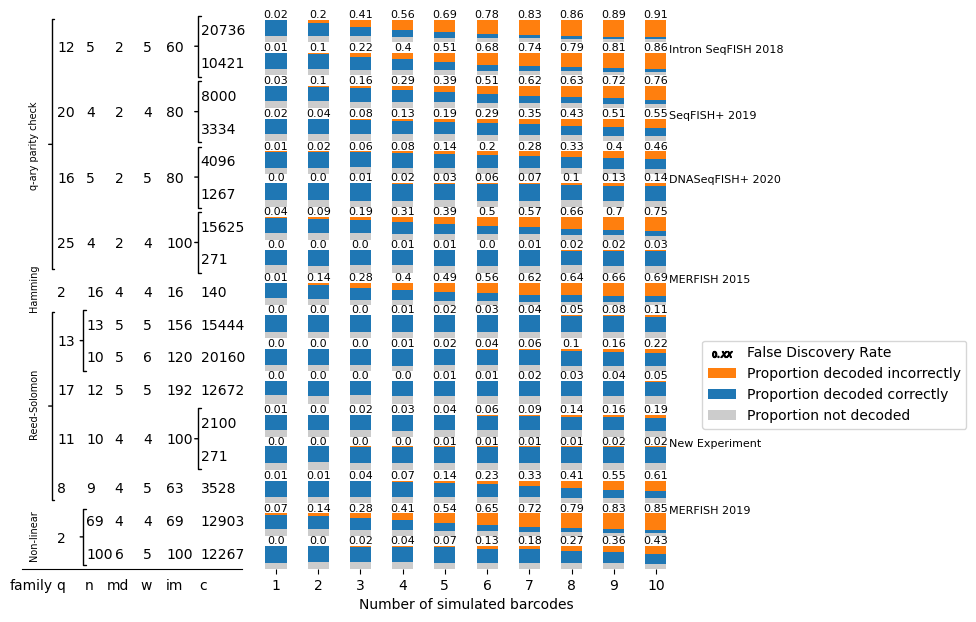

In [11]:
fig = plt.figure(figsize=(7,5.5))
ax = fig.subplot_mosaic(
    [
        ["label_tree", "seqFISH_q12_n5_k4"],
        ["label_tree", "seqFISH_intron_2018"],
        ["label_tree", "seqFISHp2019"],
        ["label_tree", "seqFISHp2019_used_only"],
        ["label_tree", 'seqFISH_q16_n5_k3'],
        ["label_tree", 'seqFISHDNA_2020'],
        ["label_tree", "full_q25_n4_k3"],
        ["label_tree", "q25_n4_k3"],
        ["label_tree", "MERFISH_2015"],
        ["label_tree", "RS_q13_n13_k9_w5"],
        ["label_tree", "RS_q13_n10_k6_w6"],
        ["label_tree", "q17n12md5w5"],
        ["label_tree", "RS_q11_n10_k7_w4"],
        ["label_tree", "q11n10k7w4"],
        ["label_tree", "RS_q8_n9_k6_w5"],
        ["label_tree", "MERFISH_2019"],
        ["label_tree", "NL_w5_md6"]
    ],
    width_ratios=[1, 2],
)
ax["label_tree"].spines.top.set_visible(False)
ax["label_tree"].spines.right.set_visible(False)
ax["label_tree"].spines.left.set_visible(False)
ax["label_tree"].spines.bottom.set_visible(False)
ax["label_tree"].tick_params(bottom=False, left=False, labelleft=False)


ax["label_tree"].plot(["family", "q", "n", "md", "w", "im", "c", ""], [1,1,1,1,1,1,1,1], markersize=0,c="w")
ax["label_tree"].set_ylim(0,1)

tree_height_factor = 10.9 * 18.5/12+ 0.01

txt_top = 0.97
bar_width = 0.5

for i, grp in enumerate(rs_ndr.groupby("ylabel")):
    print("i: ", i, "; g[0]: ", grp[0])
    code = grp[1].code.iloc[0]

    bottom = np.zeros(len(grp[1]))

    eff = grp[1]["Efficiency"]
    false = grp[1]["fp"]/grp[1]['nbarcodes']
    mis = 1 - eff - false
    fdr = grp[1]["False Discovery Rate"]

    
    ax[code].scatter([1],[0.3], s=200,marker = '$0.XX$', color='k', label="False Discovery Rate")
    p = ax[code].bar(grp[1]['Number of Barcodes'], false, bar_width, label="Proportion decoded incorrectly", bottom=1-false, color= "tab:orange")
    ax[code].bar_label(p, np.round(fdr,2),size=8, label="False Discovery Rate")
                      
    p = ax[code].bar(grp[1]['Number of Barcodes'], eff, bar_width, label="Proportion decoded correctly", bottom=mis, color="tab:blue")
    p = ax[code].bar(grp[1]['Number of Barcodes'], mis, bar_width, label="Proportion not decoded", bottom=bottom, color="#cccccc")


    
    ncws = grp[1].ncodewords.iloc[0]
    
    ax[code].spines.top.set_visible(False)
    ax[code].spines.right.set_visible(False)
    ax[code].spines.left.set_visible(False)
    ax[code].spines.bottom.set_visible(False)
    ax[code].tick_params(bottom=False, left=False, labelleft=False, labelbottom=False)

    if code_q[code] not in [11, 25, 20, 12, 16] and code_n[code] != 6:
        if code_q[code] != 13 and code not in ["MERFISH_2019", "NL_w5_md6"] :
            #pass
            ax["label_tree"].text(0.9,txt_top-plot_order_dict[code]/tree_height_factor,code_q[code])
        ax["label_tree"].text(1.9,txt_top-plot_order_dict[code]/tree_height_factor,code_n[code])
        ax["label_tree"].text(2.9,txt_top-plot_order_dict[code]/tree_height_factor,code_mds[code])
        ax["label_tree"].text(3.9,txt_top-plot_order_dict[code]/tree_height_factor,codebook_weights[code])
        ax["label_tree"].text(4.7,txt_top-plot_order_dict[code]/tree_height_factor,nimgs_dict[code])
    ax["label_tree"].text(5.9,txt_top-plot_order_dict[code]/tree_height_factor,ncws_dict[code])

ax["label_tree"].spines.bottom.set_visible(True)

plt.legend(loc='upper right', bbox_to_anchor=(1.65,10))
ax['NL_w5_md6'].set_xticks([1,2,3,4,5,6,7,8,9,10])
ax['NL_w5_md6'].set_xlabel("Number of simulated barcodes")
ax['NL_w5_md6'].tick_params(bottom=True, labelbottom=True)

print("code: ", code)

offset = 0.046 - 0.006 - 0.01
bracket_offset = 0.039 -0.009 - 0.01

ax["label_tree"].text(0.9,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - offset,code_q["seqFISH_q12_n5_k4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - offset,code_n["seqFISH_q12_n5_k4"])
ax["label_tree"].text(2.9,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - offset,code_mds["seqFISH_q12_n5_k4"])
ax["label_tree"].text(3.9,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - offset,codebook_weights["seqFISH_q12_n5_k4"])
ax["label_tree"].text(4.7,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - offset,nimgs_dict["seqFISH_q12_n5_k4"])
ax["label_tree"].annotate("",
                          (5.9,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - bracket_offset),
                          (5.6,txt_top-plot_order_dict["seqFISH_q12_n5_k4"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )

ax["label_tree"].text(0.9,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - offset,code_q["seqFISHp2019"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - offset,code_n["seqFISHp2019"])
ax["label_tree"].text(2.9,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - offset,code_mds["seqFISHp2019"])
ax["label_tree"].text(3.9,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - offset,codebook_weights["seqFISHp2019"])
ax["label_tree"].text(4.7,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - offset,nimgs_dict["seqFISHp2019"])
ax["label_tree"].annotate("",
                          (5.9,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - bracket_offset),
                          (5.6,txt_top-plot_order_dict["seqFISHp2019"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )

ax["label_tree"].text(0.9,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - offset,code_q["seqFISH_q16_n5_k3"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - offset,code_n["seqFISH_q16_n5_k3"])
ax["label_tree"].text(2.9,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - offset,code_mds["seqFISH_q16_n5_k3"])
ax["label_tree"].text(3.9,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - offset,codebook_weights["seqFISH_q16_n5_k3"])
ax["label_tree"].text(4.7,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - offset,nimgs_dict["seqFISH_q16_n5_k3"])
ax["label_tree"].annotate("",
                          (5.9,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - bracket_offset),
                          (5.6,txt_top-plot_order_dict["seqFISH_q16_n5_k3"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )

ax["label_tree"].text(0.9,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - offset,code_q["full_q25_n4_k3"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - offset,code_n["full_q25_n4_k3"])
ax["label_tree"].text(2.9,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - offset,code_mds["full_q25_n4_k3"])
ax["label_tree"].text(3.9,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - offset,codebook_weights["full_q25_n4_k3"])
ax["label_tree"].text(4.7,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - offset,nimgs_dict["full_q25_n4_k3"])
ax["label_tree"].annotate("",
                          (5.9,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - bracket_offset),
                          (5.6,txt_top-plot_order_dict["full_q25_n4_k3"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )


ax["label_tree"].text(0.9,txt_top-plot_order_dict["RS_q13_n13_k9_w5"]/tree_height_factor-offset,code_q["RS_q13_n13_k9_w5"])
ax["label_tree"].annotate("",
                          (1.9,txt_top-plot_order_dict["RS_q13_n13_k9_w5"]/tree_height_factor - bracket_offset),
                          (1.6,txt_top-plot_order_dict["RS_q13_n13_k9_w5"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )

ax["label_tree"].text(0.9,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor-offset,code_q["RS_q11_n10_k7_w4"])
ax["label_tree"].text(1.9,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor-offset,code_n["RS_q11_n10_k7_w4"])
ax["label_tree"].text(2.9,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor-offset,code_mds["RS_q11_n10_k7_w4"])
ax["label_tree"].text(3.9,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor-offset,codebook_weights["RS_q11_n10_k7_w4"])
ax["label_tree"].text(4.7,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor-offset,nimgs_dict["RS_q11_n10_k7_w4"])
ax["label_tree"].annotate("",
                          (5.9,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor - bracket_offset),
                          (5.6,txt_top-plot_order_dict["RS_q11_n10_k7_w4"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.2, lengthB=0.2,angleB=0"}
                         )

ax['seqFISH_intron_2018'].text(10.3,1,"Intron SeqFISH 2018",size=8)
ax['seqFISHp2019_used_only'].text(10.3,1,"SeqFISH+ 2019",size=8)
ax['seqFISHDNA_2020'].text(10.3,1,"DNASeqFISH+ 2020",size=8)
ax['MERFISH_2015'].text(10.3,1,"MERFISH 2015",size=8)
ax['q11n10k7w4'].text(10.3,1,"New Experiment",size=8)
ax['MERFISH_2019'].text(10.3,1,"MERFISH 2019",size=8)


brackets = []
pc_bracket = FancyArrowPatch((0.0,0.8),(0.2,0.8), arrowstyle={'arrowstyle':"-[,widthB=0.0, lengthB=0.2, angleB=0"}, mutation_scale=42)

fig.text(0.06,txt_top-plot_order_dict["seqFISHDNA_2020"]/tree_height_factor+0.02,"q-ary parity check",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor-bracket_offset),
                          (0.5,txt_top-plot_order_dict["seqFISHp2019_used_only"]/tree_height_factor-bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=9, lengthB=0.2,angleB=0"}
                         )

fig.text(0.06,0.47,"Hamming",rotation="vertical",fontsize=7)

RS_bracket = FancyArrowPatch((45,265),(55,265), arrowstyle="-[,widthB=2.1, lengthB=0.2, angleB=0", mutation_scale=42)
brackets.append(RS_bracket)
fig.text(0.06,0.24,"Reed-Solomon",rotation="vertical",fontsize=7)
ax["label_tree"].annotate("",
                          (0.8,txt_top-plot_order_dict["q17n12md5w5"]/tree_height_factor-bracket_offset),
                          (0.5,txt_top-plot_order_dict["q17n12md5w5"]/tree_height_factor-bracket_offset),
                          arrowprops={'arrowstyle':"-[,widthB=6.8, lengthB=0.2,angleB=0"}
                         )

ax["label_tree"].text(-0.10,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor-0.06,"Non-linear",rotation="vertical",fontsize=7)
ax["label_tree"].text(0.9,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor-offset,code_q["MERFISH_2019"])
ax["label_tree"].annotate("",
                          (1.9,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor - bracket_offset),
                          (1.6,txt_top-plot_order_dict["MERFISH_2019"]/tree_height_factor - bracket_offset), 
                          arrowprops={'arrowstyle':"-[,widthB=2.0, lengthB=0.2,angleB=0"}
                         )


plt.subplots_adjust(left=0.05,
                    bottom=0.0, 
                    right=1.0, 
                    top=1, 
                    wspace=0.01, 
                    hspace=0.4)

plt.savefig('figS2.pdf', bbox_inches = 'tight')